# Tehran house price prediction

The project is built in four steps, each one adding something to the previous:

1. Baseline models using only the property features
2. The same models with the neighborhood from the address
3. Polynomial regression
4. Predicting the log of the price

Every score is a 5-fold cross-validation average, so the numbers are comparable across steps.

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)

In [2]:
df = pd.read_csv('../data/raw/tehran_house_prices.csv')
print(len(df))
df.head()

3479


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


## Cleaning

Rows with a missing address or invalid area are dropped, `Area` outliers are removed with the 1.5×IQR rule, and exact duplicate listings are removed so the same listing cannot end up in both the training and the test fold.

In [3]:
df = df[df['Address'].notna()]
df = df[df['Address'].str.strip() != '']

df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
df = df.dropna(subset=['Area'])

q1 = df['Area'].quantile(0.25)
q3 = df['Area'].quantile(0.75)
iqr = q3 - q1
df = df[(df['Area'] >= q1 - 1.5 * iqr) & (df['Area'] <= q3 + 1.5 * iqr)]
print('after outlier filter:', len(df))

df = df.drop_duplicates(subset=['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address', 'Price'])
print('after removing duplicates:', len(df))

after outlier filter: 3212
after removing duplicates: 3010


In [4]:
features = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']
df[['Parking', 'Warehouse', 'Elevator']] = df[['Parking', 'Warehouse', 'Elevator']].astype(int)

y = df['Price']
cv = KFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(models, X, y):
    rows = []
    for name, model in models.items():
        scores = cross_validate(
            model, X, y, cv=cv,
            scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
        )
        rows.append({
            'Model': name,
            'R2': scores['test_r2'].mean(),
            'R2_std': scores['test_r2'].std(),
            'MAE': -scores['test_neg_mean_absolute_error'].mean(),
            'RMSE': -scores['test_neg_root_mean_squared_error'].mean(),
        })
    return pd.DataFrame(rows)


def plot_predictions(y_true, y_pred, title, path, degree=3):
    actual = np.asarray(y_true) / 1e9
    predicted = np.asarray(y_pred) / 1e9

    xs = np.linspace(actual.min(), actual.max(), 300)
    curve = np.polyval(np.polyfit(actual, predicted, degree), xs)
    low = min(actual.min(), predicted.min())
    high = max(actual.max(), predicted.max())

    plt.figure(figsize=(9, 6.5))
    plt.scatter(actual, predicted, s=14, alpha=0.5)
    plt.plot([low, high], [low, high], '--', color='tab:blue', label='Perfect prediction')
    plt.plot(xs, curve, color='orange', linewidth=2, label='Trend')
    plt.xlabel('Actual price (billion Toman)')
    plt.ylabel('Predicted price (billion Toman)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

## Step 1: property features only

Features: `Area`, `Room`, `Parking`, `Warehouse`, `Elevator`. The address is not used, so the models know nothing about location.

In [5]:
X_base = df[features]

baseline_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

baseline_df = evaluate(baseline_models, X_base, y)
baseline_df.to_csv('../outputs/baseline_metrics.csv', index=False)
baseline_df.sort_values('R2', ascending=False)

,Model,R2,R2_std,MAE,RMSE
3,Gradient Boosting,0.612321,0.013198,1.542792e+09,2.412477e+09
2,Random Forest,0.585115,0.030489,1.607007e+09,2.490733e+09
1,Decision Tree,0.558609,0.042739,1.650052e+09,2.565518e+09
0,Linear Regression,0.547266,0.008003,1.766404e+09,2.609403e+09


## Step 2: adding the address

Addresses are lowercased and stripped, and direction words (north, south, east, west and so on) are removed so that variants of one neighborhood share a label. The neighborhood is one-hot encoded inside the pipeline, so the encoder only learns categories from the training folds.

In [6]:
def normalize_address(address):
    address = str(address).strip().lower()
    for word in ['west', 'east', 'north', 'south', 'northern', 'southern', 'central']:
        address = re.sub(rf'\b{word}\b', '', address)
    return re.sub(r'\s+', ' ', address).strip()


df['Address_Main'] = df['Address'].apply(normalize_address)

print('Before:', df['Address'].nunique())
print('After:', df['Address_Main'].nunique())

Before: 187
After: 180


In [7]:
(
    df[['Address', 'Address_Main']]
    .drop_duplicates()
    .query('Address != Address_Main')
    .sort_values('Address_Main')
)

,Address,Address_Main
370,Abazar,abazar
49,Abbasabad,abbasabad
2471,Abuzar,abuzar
97,Afsarieh,afsarieh
2152,Ahang,ahang
...,...,...
1103,Yousef Abad,yousef abad
14,Zafar,zafar
203,Zaferanieh,zaferanieh
32,Zargandeh,zargandeh


### Neighborhood price factor (exploration only)

For every Punak listing, listings from other neighborhoods with an area within 10% are collected and the price ratio is computed. The median ratio per neighborhood gives a rough price factor relative to Punak. This table is not used as a model feature.

In [8]:
base_address = 'punak'
base_rows = df[df['Address_Main'] == base_address]

parts = []
for _, row in base_rows.iterrows():
    similar = df[
        (df['Area'] >= row['Area'] * 0.9)
        & (df['Area'] <= row['Area'] * 1.1)
        & (df['Address_Main'] != base_address)
    ].copy()
    similar['Price_Ratio'] = similar['Price'] / row['Price']
    parts.append(similar)

ratios = pd.concat(parts, ignore_index=True)

address_factors = (
    ratios.groupby('Address_Main')
    .agg(Price_Factor=('Price_Ratio', 'median'), Comparisons=('Price_Ratio', 'count'))
    .sort_values('Price_Factor', ascending=False)
)
address_factors

,Price_Factor,Comparisons
Address_Main,,
elahieh,2.067663,90
velenjak,1.903509,127
zaferanieh,1.867359,202
niavaran,1.800000,578
kamranieh,1.768480,134
...,...,...
parand,0.136471,3543
salehabad,0.135752,14
shahedshahr,0.128353,108


In [9]:
X = df[features + ['Address_Main']]


def with_address(model):
    columns = ColumnTransformer([
        ('numeric', 'passthrough', features),
        ('address', OneHotEncoder(handle_unknown='ignore'), ['Address_Main']),
    ])
    return make_pipeline(columns, model)


address_models = {name: with_address(model) for name, model in baseline_models.items()}

address_df = evaluate(address_models, X, y)
address_df.to_csv('../outputs/neighborhood_metrics.csv', index=False)
address_df.sort_values('R2', ascending=False)

,Model,R2,R2_std,MAE,RMSE
0,Linear Regression,0.803650,0.019156,1.023210e+09,1.721397e+09
2,Random Forest,0.784540,0.016464,9.425886e+08,1.799393e+09
3,Gradient Boosting,0.784024,0.023069,1.073129e+09,1.802801e+09
1,Decision Tree,0.695712,0.036447,1.083058e+09,2.127273e+09


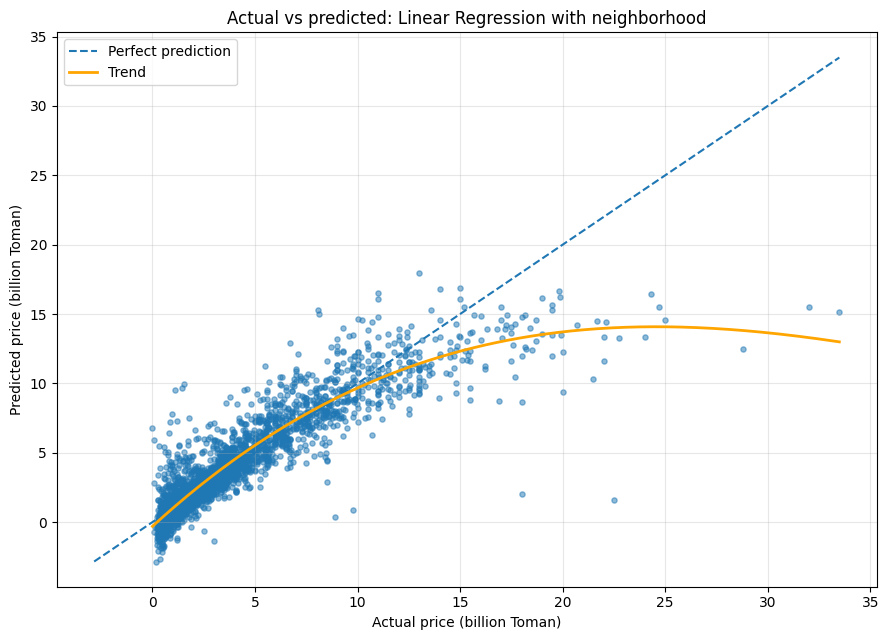

In [10]:
linear_pred = cross_val_predict(address_models['Linear Regression'], X, y, cv=cv)

plot_predictions(
    y, linear_pred,
    'Actual vs predicted: Linear Regression with neighborhood',
    '../outputs/actual_vs_predicted.png',
)

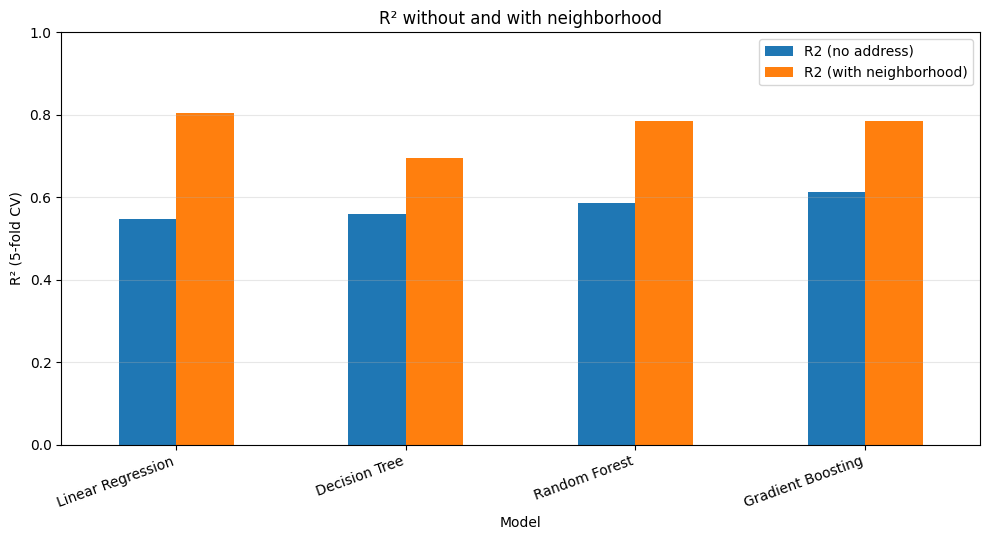

,Model,R2 (no address),R2 (with neighborhood)
0,Linear Regression,0.547266,0.803650
1,Decision Tree,0.558609,0.695712
2,Random Forest,0.585115,0.784540
3,Gradient Boosting,0.612321,0.784024


In [11]:
r2 = baseline_df[['Model', 'R2']].merge(
    address_df[['Model', 'R2']], on='Model', suffixes=(' (no address)', ' (with neighborhood)')
)

r2.set_index('Model').plot(kind='bar', figsize=(10, 5.5))
plt.ylabel('R² (5-fold CV)')
plt.title('R² without and with neighborhood')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../outputs/r2_comparison.png', dpi=150)
plt.show()

r2

## Step 3: polynomial regression

Polynomial terms are built for `Area` and `Room` (for degree 2: `Area²`, `Area·Room`, `Room²`) and then standardized, followed by a linear model. The binary columns and the one-hot neighborhoods are not expanded: ~180 neighborhood columns would produce thousands of features for about 2,400 training rows.

Standardizing matters. Without it `Area³` reaches millions next to 0/1 columns, the least-squares fit becomes numerically unstable and the degree 3 model collapses (R² around 0.58 in a test run).

In [12]:
def polynomial_model(degree, log_target=False):
    numeric = Pipeline([
        ('poly', PolynomialFeatures(degree, include_bias=False)),
        ('scale', StandardScaler()),
    ])
    columns = ColumnTransformer([
        ('numeric', numeric, ['Area', 'Room']),
        ('flags', 'passthrough', ['Parking', 'Warehouse', 'Elevator']),
        ('address', OneHotEncoder(handle_unknown='ignore'), ['Address_Main']),
    ])
    model = make_pipeline(columns, LinearRegression())
    if log_target:
        model = TransformedTargetRegressor(model, func=np.log1p, inverse_func=np.expm1)
    return model


degree_df = evaluate(
    {f'Degree {d}': polynomial_model(d) for d in [1, 2, 3, 4]}, X, y
)
degree_df

,Model,R2,R2_std,MAE,RMSE
0,Degree 1,0.803623,0.019191,1.023304e+09,1.721516e+09
1,Degree 2,0.825739,0.012924,9.229179e+08,1.620426e+09
2,Degree 3,0.821458,0.014658,9.187797e+08,1.641549e+09
3,Degree 4,0.824981,0.013756,9.121446e+08,1.624352e+09


In [13]:
poly_df = evaluate({'Polynomial Regression (deg 2)': polynomial_model(2)}, X, y)

polynomial_results = pd.concat([address_df, poly_df], ignore_index=True)
polynomial_results.to_csv('../outputs/polynomial_metrics.csv', index=False)
polynomial_results.sort_values('R2', ascending=False)

,Model,R2,R2_std,MAE,RMSE
4,Polynomial Regression (deg 2),0.825739,0.012924,9.229179e+08,1.620426e+09
0,Linear Regression,0.803650,0.019156,1.023210e+09,1.721397e+09
2,Random Forest,0.784540,0.016464,9.425886e+08,1.799393e+09
3,Gradient Boosting,0.784024,0.023069,1.073129e+09,1.802801e+09
1,Decision Tree,0.695712,0.036447,1.083058e+09,2.127273e+09


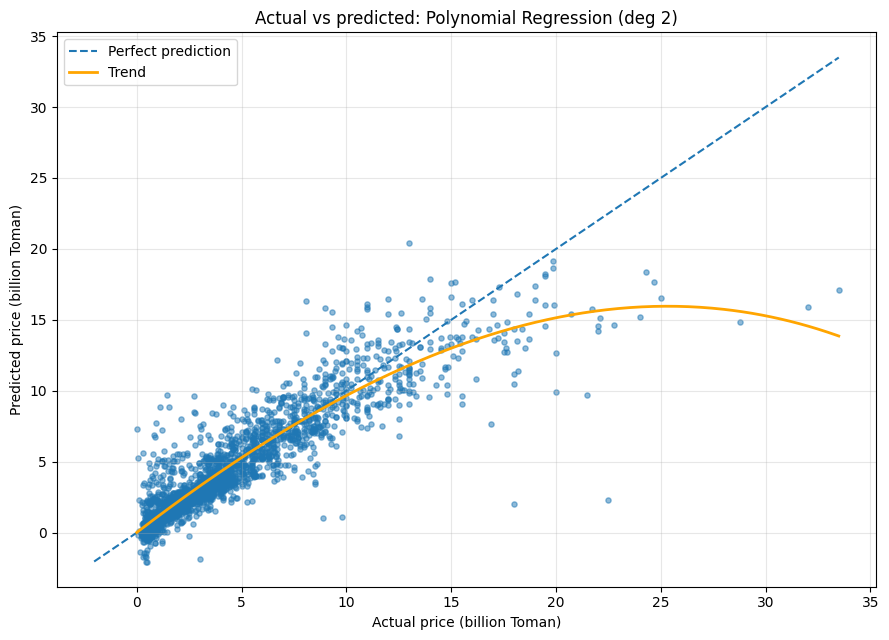

In [14]:
poly_pred = cross_val_predict(polynomial_model(2), X, y, cv=cv)

plot_predictions(
    y, poly_pred,
    'Actual vs predicted: Polynomial Regression (deg 2)',
    '../outputs/actual_vs_predicted_polynomial.png',
)

## Step 4: predicting the log of the price

Prices are strongly right-skewed, so the largest apartments dominate the squared error. Here the models are trained on `log1p(Price)` and the predictions are converted back with `expm1`. Metrics are still computed on the original Toman scale.

In [15]:
def log_target(model):
    return TransformedTargetRegressor(model, func=np.log1p, inverse_func=np.expm1)


log_models = {
    'Linear Regression (log)': log_target(address_models['Linear Regression']),
    'Polynomial Regression deg 2 (log)': polynomial_model(2, log_target=True),
    'Random Forest (log)': log_target(address_models['Random Forest']),
    'Gradient Boosting (log)': log_target(address_models['Gradient Boosting']),
}

log_df = evaluate(log_models, X, y)

log_results = pd.concat([polynomial_results, log_df], ignore_index=True)
log_results.to_csv('../outputs/log_target_metrics.csv', index=False)
log_results.sort_values('R2', ascending=False)

,Model,R2,R2_std,MAE,RMSE
6,Polynomial Regression deg 2 (log),0.844467,0.023190,7.740052e+08,1.530906e+09
5,Linear Regression (log),0.840719,0.025930,7.883394e+08,1.545696e+09
4,Polynomial Regression (deg 2),0.825739,0.012924,9.229179e+08,1.620426e+09
0,Linear Regression,0.803650,0.019156,1.023210e+09,1.721397e+09
2,Random Forest,0.784540,0.016464,9.425886e+08,1.799393e+09
3,Gradient Boosting,0.784024,0.023069,1.073129e+09,1.802801e+09
7,Random Forest (log),0.775691,0.017427,9.584997e+08,1.839080e+09
8,Gradient Boosting (log),0.746957,0.038617,1.067829e+09,1.956185e+09
1,Decision Tree,0.695712,0.036447,1.083058e+09,2.127273e+09


In [16]:
degree_log_df = evaluate(
    {f'Degree {d} (log)': polynomial_model(d, log_target=True) for d in [1, 2, 3, 4]}, X, y
)
degree_log_df

,Model,R2,R2_std,MAE,RMSE
0,Degree 1 (log),0.840680,0.026008,7.883707e+08,1.545875e+09
1,Degree 2 (log),0.844467,0.023190,7.740052e+08,1.530906e+09
2,Degree 3 (log),0.745733,0.200539,7.954362e+08,1.887353e+09
3,Degree 4 (log),0.836819,0.023579,7.757336e+08,1.567581e+09


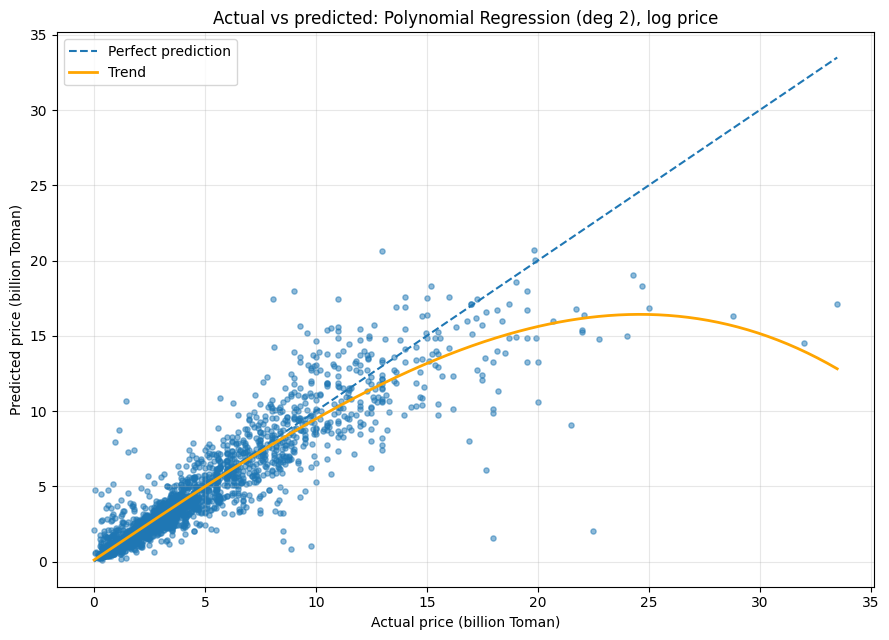

In [17]:
log_pred = cross_val_predict(polynomial_model(2, log_target=True), X, y, cv=cv)

plot_predictions(
    y, log_pred,
    'Actual vs predicted: Polynomial Regression (deg 2), log price',
    '../outputs/actual_vs_predicted_log.png',
)